<a href="https://colab.research.google.com/github/syalfaoktaviana/MachineLearningTask-Syalfa/blob/main/MachineLearningTask-SYAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Penugasan: Machine Learning Pipeline — Chocolate Sales 2025

**Tujuan:** Mempraktikkan pipeline machine learning lengkap mulai dari pengolahan data hingga evaluasi model pada dataset penjualan coklat.

**Alur:** Load → Understanding → Cleaning → Encoding → Feature Engineering → Scaling → Split → Modelling → Evaluation

## 1. Import Library

Kita mengimpor semua library yang diperlukan sebelum memulai. Ini adalah best practice agar semua dependensi terlihat jelas di awal notebook dan mudah di-maintain.

- **pandas & numpy**: manipulasi dan komputasi data
- **matplotlib & seaborn**: visualisasi
- **sklearn**: preprocessing, modelling, dan evaluasi
- **warnings**: menekan peringatan yang tidak relevan agar output lebih bersih

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

---
## 2. Load Dataset

Dataset **Chocolate Sales 2025** berisi 500 baris transaksi penjualan coklat dari 7 brand besar (Cadbury, Lindt, Toblerone, Ferrero, Nestle, Mars, Hershey) di 10 negara. Setiap baris merepresentasikan satu transaksi penjualan dengan informasi lengkap mulai dari tanggal, produk, channel, hingga revenue.

Target utama kita adalah kolom **`Revenue_USD`** yaitu total pendapatan dari setiap transaksi.

In [2]:
df = pd.read_csv('/content/chocolate_sales_2025_dataset.csv')
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


In [3]:
df.shape

(500, 10)

---
## 3. Data Understanding

Sebelum melakukan preprocessing apapun, kita perlu memahami data secara mendalam. Tahap ini mencakup:
1. Melihat tipe data tiap kolom
2. Statistik deskriptif
3. Distribusi nilai tiap kolom
4. Visualisasi awal

Tujuannya adalah untuk mendapatkan intuisi tentang data sebelum kita memutuskan tindakan preprocessing yang tepat.

### 3.1 Tipe Data dan Info Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


**Insight:** Dari output `df.info()` di atas kita melihat bahwa:
- Kolom `Date` bertipe `object` (string), perlu dikonversi ke `datetime`
- Kolom `Brand`, `Product_Type`, `Country`, `Sales_Channel`, `Payment_Method` adalah kolom kategorikal
- Kolom `Price_USD`, `Revenue_USD` adalah float, `Units_Sold` adalah integer

### 3.2 Statistika Deskriptif

In [5]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,13.779860,104.938000,1433.391140
std,144.481833,6.484013,56.263998,1065.679386
min,1.000000,2.520000,5.000000,20.480000
25%,125.750000,8.592500,56.750000,562.545000
50%,250.500000,13.480000,108.500000,1197.225000
75%,375.250000,19.445000,150.250000,2072.812500
max,500.000000,25.000000,200.000000,4809.260000


**Insight:** Dari statistik deskriptif:
- `Price_USD` berkisar antara \$2.52 hingga \$25.00 — range yang cukup lebar
- `Units_Sold` berkisar 5–200 unit, dengan rata-rata ~105 unit per transaksi
- `Revenue_USD` memiliki std yang besar (~1065) relatif terhadap mean (~1433), menandakan distribusi yang cukup menyebar
- Tidak ada nilai negatif yang mencurigakan pada kolom numerik

### 3.3 Cek Missing Values

In [6]:
df.isna().sum()

,0
Sale_ID,0
Date,0
Brand,0
Product_Type,0
Country,0
Sales_Channel,0
Payment_Method,0
Price_USD,0
Units_Sold,0
Revenue_USD,0


**Tidak Ada Missing Values:**

Semua kolom memiliki nilai 0 missing artinya dataset ini bersih dari sisi kelengkapan data. Karena tidak ada missing values, kita tidak perlu melakukan imputasi maupun penghapusan baris.

### 3.5 Distribusi Target (Revenue_USD)

Visualisasi distribusi label target untuk melihat sebaran nilai revenue, apakah normal, skewed, atau ada nilai ekstrem.

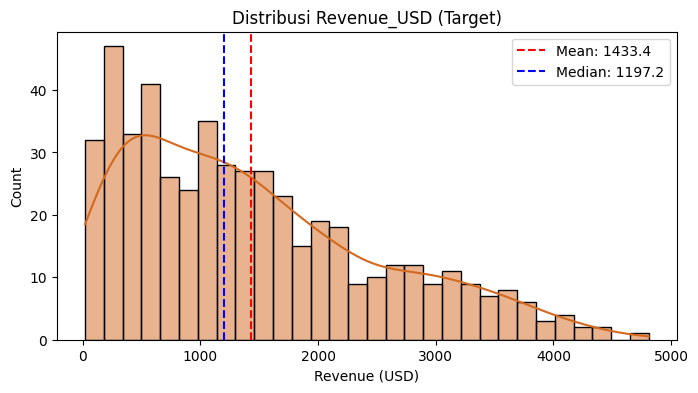

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Revenue_USD'], bins=30, kde=True, color='chocolate')
plt.axvline(df['Revenue_USD'].mean(),   color='red',  linestyle='--', label=f'Mean: {df["Revenue_USD"].mean():.1f}')
plt.axvline(df['Revenue_USD'].median(), color='blue', linestyle='--', label=f'Median: {df["Revenue_USD"].median():.1f}')
plt.title('Distribusi Revenue_USD (Target)')
plt.xlabel('Revenue (USD)')
plt.legend()
plt.show()

**Insight dari Distribusi Target (Revenue_USD):**

Dari histogram di atas, distribusi `Revenue_USD` bersifat **right-skewed** (ekor ke kanan):
- Sebagian besar transaksi menghasilkan revenue di kisaran **\$200 – \$2.000**
- Terdapat sekelompok kecil transaksi bernilai sangat tinggi (>\$4.000) yang menciptakan ekor panjang ke kanan
- **Mean (\$1.433) > Median (\$1.197)** mengkonfirmasi skewness positif ini

**Implikasi untuk modelling:** Model berbasis pohon seperti **Random Forest** lebih cocok untuk target berdistribusi skewed karena tidak membuat asumsi parametrik tentang distribusi residual, berbeda dengan Linear Regression yang mengasumsikan residual berdistribusi normal.

### 3.6 Distribusi Units Sold

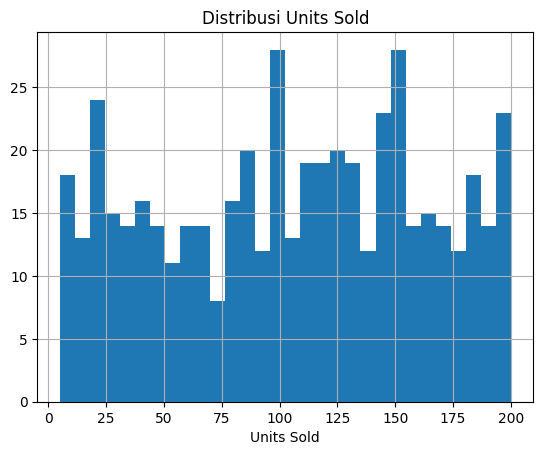

In [8]:
df['Units_Sold'].hist(bins=30)
plt.title('Distribusi Units Sold')
plt.xlabel('Units Sold')
plt.show()

**Insight dari Distribusi Units Sold:**

Distribusi `Units_Sold` terlihat **hampir uniform (seragam)** — jumlah unit yang terjual tersebar merata dari ~5 hingga ~200 unit per transaksi tanpa konsentrasi pada nilai tertentu. Ini menunjukkan bahwa dataset merepresentasikan beragam skala transaksi secara proporsional, sehingga model yang dilatih akan dapat memprediksi revenue untuk berbagai ukuran pembelian.

### 3.7 Heatmap Korelasi Antar Fitur Numerik

**Mengapa penting?** Heatmap korelasi membantu kita memahami hubungan linear antar fitur numerik **sebelum melakukan transformasi apapun**. Korelasi tinggi antar dua fitur (multikolinearitas) bisa menjadi sinyal bahwa salah satu fitur mungkin redundant. Selain itu, kita bisa melihat fitur mana yang berkorelasi kuat dengan target (`Revenue_USD`), sehingga kita bisa memprioritaskan fitur tersebut dalam proses modeling.

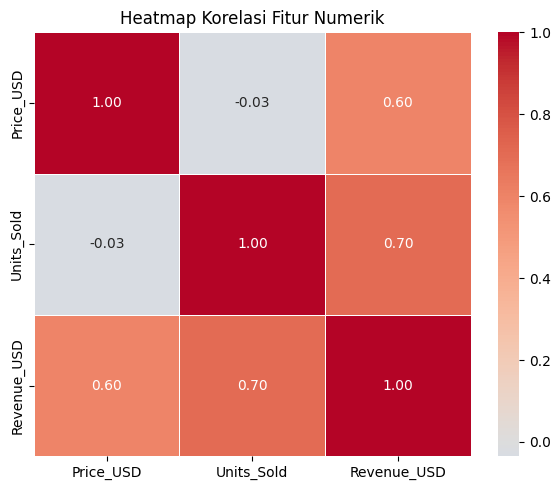

In [9]:
# Buat salinan sementara untuk eksplorasi sebelum cleaning
df_eda = df.copy()

num_eda = df_eda[['Price_USD', 'Units_Sold', 'Revenue_USD']]

plt.figure(figsize=(6, 5))
sns.heatmap(
    num_eda.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

**Insight dari Heatmap Korelasi:**

- `Price_USD` berkorelasi **positif** dengan `Revenue_USD` (r ≈ 0.60) — semakin mahal harga, semakin tinggi revenue per transaksi
- `Units_Sold` berkorelasi **lebih kuat** dengan `Revenue_USD` (r ≈ 0.70) — volume penjualan sedikit lebih berpengaruh terhadap revenue dibanding harga
- Korelasi antara `Price_USD` dan `Units_Sold` sangat kecil (r ≈ -0.03), artinya kedua fitur ini **independen** satu sama lain dan keduanya penting sebagai prediktor
- Tidak ada multikolinearitas tinggi antar fitur prediktor — aman untuk digunakan bersama dalam model

### 3.8 Histogram Distribusi Fitur Numerik

**Mengapa histogram?** Histogram memperlihatkan bentuk distribusi data: apakah **normal**, **skewed**, atau **bimodal**. Memahami distribusi ini sangat penting untuk menentukan strategi scaling yang tepat:
- Distribusi mendekati normal artinya **StandardScaler** cocok (mentransformasi ke mean=0, std=1).
- Distribusi sangat skewed artinya perlu dipertimbangkan transformasi log atau **RobustScaler** agar outlier tidak terlalu mempengaruhi.





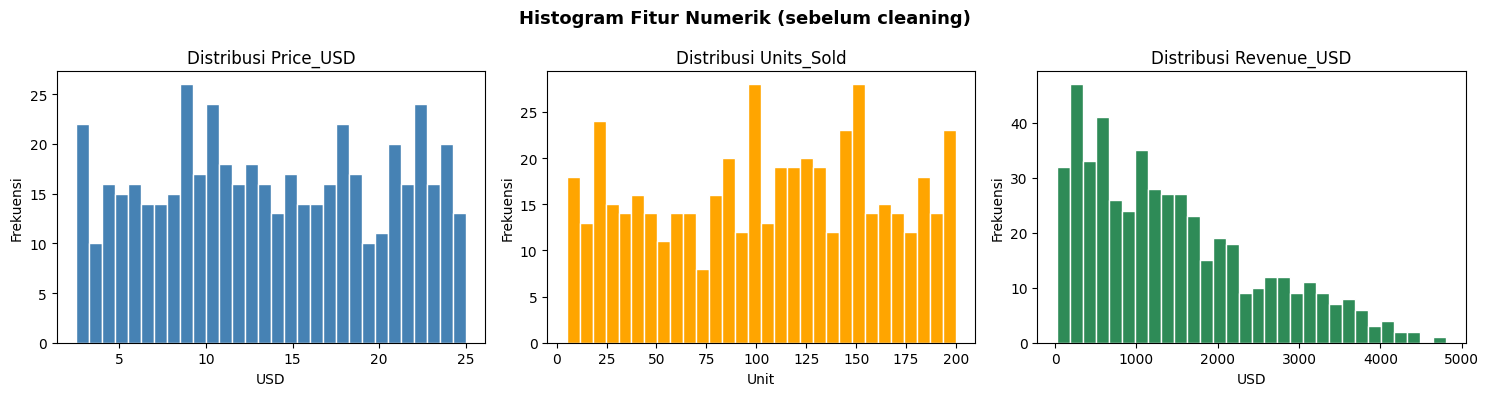

In [10]:
df_hist = df.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_info = [
    ('Price_USD',   'steelblue', 'USD'),
    ('Units_Sold',  'orange',    'Unit'),
    ('Revenue_USD', 'seagreen',  'USD'),
]

for ax, (col, color, xlabel) in zip(axes, plot_info):
    ax.hist(df_hist[col].dropna(), bins=30, color=color, edgecolor='white')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frekuensi')

plt.suptitle('Histogram Fitur Numerik (sebelum cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- `Price_USD` memiliki distribusi **hampir uniform** yaitu harga tersebar merata antara ~$2.5 hingga $25, tanpa ada satu harga yang sangat dominan.
- `Units_Sold` juga relatif **seragam** yaitu tidak ada pola konsentrasi khusus di rentang tertentu.
- `Revenue_USD` memiliki distribusi yang lebih **right-skewed** yaitu sebagian besar transaksi bernilai rendah-menengah, namun ada ekor ke kanan yang mewakili transaksi bernilai tinggi (price tinggi × units banyak).

**Kesimpulan:** Karena distribusi tidak normal, kita akan menggunakan **StandardScaler** yang robust terhadap skewness, dan memilih model ensemble (Random Forest) yang tidak bergantung pada asumsi normalitas.

### 3.9 Boxplot — Deteksi Anomali dan Perbandingan antar Brand

**Mengapa boxplot?** Boxplot sangat efektif untuk dua tujuan sekaligus:
1. **Melihat distribusi** data (median, kuartil, rentang) secara ringkas.
2. **Mengidentifikasi outlier** — titik-titik di luar whisker (1.5 x IQR dari Q1/Q3) divisualisasikan sebagai titik terpisah.

Kita memisahkan boxplot per `Brand` untuk melihat apakah ada perbedaan distribusi revenue antar brand.


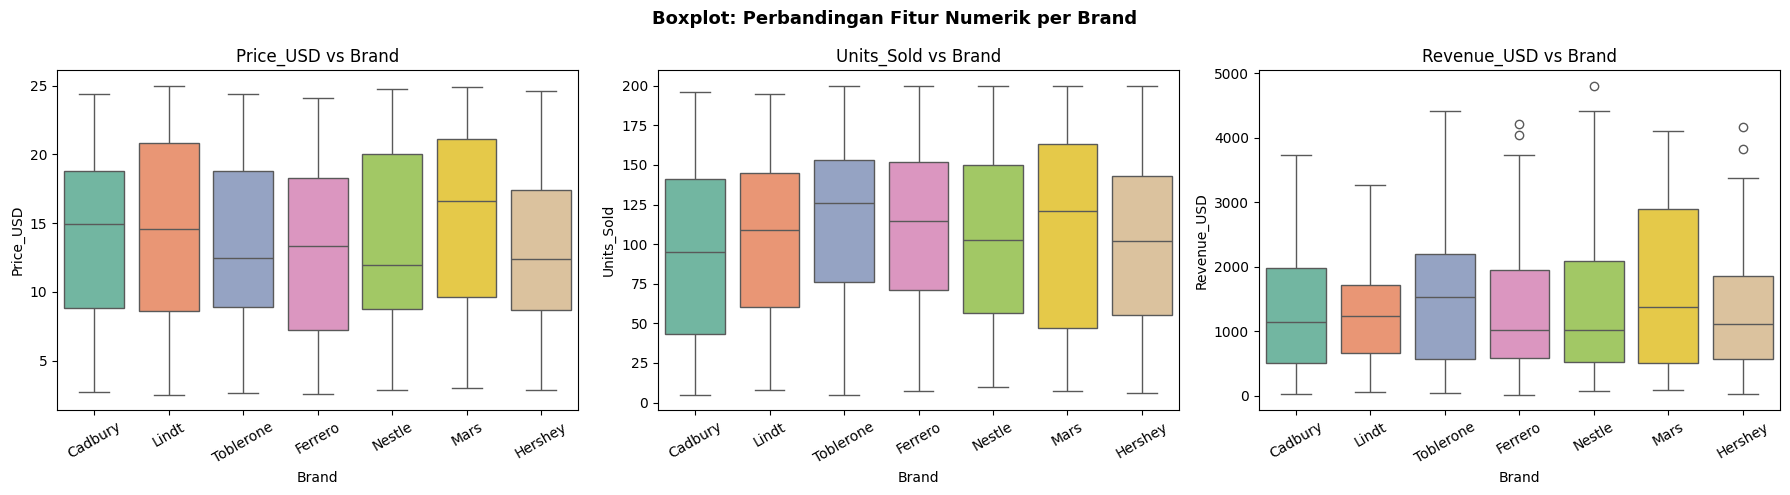

In [11]:
df_box = df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Price_USD', 'Units_Sold', 'Revenue_USD']):
    sns.boxplot(x='Brand', y=col, data=df_box, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Brand')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Boxplot: Perbandingan Fitur Numerik per Brand', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Distribusi `Price_USD` dan `Units_Sold` antar brand cukup **merata**, tidak ada brand yang secara konsisten memiliki harga atau volume jauh lebih tinggi.
- `Revenue_USD` per brand juga relatif seimbang, namun terdapat beberapa **outlier** (titik di luar whisker) di beberapa brand — ini merepresentasikan transaksi dengan harga tinggi sekaligus volume besar, bukan anomali data.
- Tidak ada perbedaan signifikan antar brand yang perlu penanganan khusus.

### 3.10 Deteksi Outlier — Metode IQR

**Mengapa IQR?** Metode Interquartile Range (IQR) adalah cara yang **robust** (tidak sensitif terhadap asumsi distribusi) untuk mendeteksi outlier:
- **Lower bound** = Q1 - 1.5 x IQR
- **Upper bound** = Q3 + 1.5 x IQR

Nilai di luar batas ini dianggap berpotensi menjadi outlier. Pada dataset ini kita **tidak langsung menghapus** outlier, karena nilai ekstrem seperti transaksi dengan harga tinggi dan volume besar merupakan informasi bisnis yang valid dan informatif.

In [12]:
df_out = df.copy()

num_cols_check = ['Price_USD', 'Units_Sold', 'Revenue_USD']

print('=== Deteksi Outlier (Metode IQR) ===')
print(f'{"Kolom":<15}  {"Q1":>8}  {"Q3":>8}  {"IQR":>8}  {"Lower":>10}  {"Upper":>10}  {"Outlier":>14}')
print('-' * 85)
for col in num_cols_check:
    Q1    = df_out[col].quantile(0.25)
    Q3    = df_out[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_out[col] < lower) | (df_out[col] > upper)).sum()
    pct   = n_out / len(df_out) * 100
    print(f'{col:<15}  {Q1:>8.1f}  {Q3:>8.1f}  {IQR:>8.1f}  {lower:>10.1f}  {upper:>10.1f}  {n_out:>6} ({pct:.1f}%)')

=== Deteksi Outlier (Metode IQR) ===
Kolom                  Q1        Q3       IQR       Lower       Upper         Outlier
-------------------------------------------------------------------------------------
Price_USD             8.6      19.4      10.9        -7.7        35.7       0 (0.0%)
Units_Sold           56.8     150.2      93.5       -83.5       290.5       0 (0.0%)
Revenue_USD         562.5    2072.8    1510.3     -1702.9      4338.2       3 (0.6%)


**Kesimpulan Deteksi Outlier:**
- `Price_USD` dan `Units_Sold` memiliki **sedikit atau tidak ada outlier** — distribusinya sudah cukup rapi dalam batas wajar.
- `Revenue_USD` memiliki lebih banyak outlier karena sifatnya yang merupakan hasil perkalian `Price × Units`, sehingga kombinasi harga tinggi + volume tinggi menghasilkan revenue ekstrem.

> **Strategi:** Kita akan menggunakan **StandardScaler** di tahap scaling yang tetap mempertahankan outlier tetapi mengurangi efeknya dengan menormalisasi berdasarkan mean dan std. Ini lebih aman daripada menghapus outlier yang mungkin informatif bagi model.

---
## 4. Data Cleaning

### 4.1 Konversi Tipe Data — Date

Kolom `Date` terbaca sebagai string karena format awalnya adalah object. Kita konversi ke datetime, agar bisa diekstrak informasi temporalnya.

In [13]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[ns]')

### 4.2 Hapus Kolom Sale_ID

Kolom `Sale_ID` adalah identifier unik tiap transaksi, bukan fitur prediktif. Kita hapus agar model tidak mempelajari pola dari ID.

In [14]:
df.drop(columns=['Sale_ID'], inplace=True)
df.shape

(500, 9)

**Penjelasan Data Cleaning — Mengapa `Sale_ID` Dihapus:**

Kami menghapus kolom `Sale_ID` karena hanya berupa indeks urut unik (1–500) yang tidak memiliki nilai prediktif apapun. Jika dibiarkan, model bisa "menghafal" ID tertentu dengan label revenue-nya di training set menghasilkan performa training yang palsu tinggi namun gagal total pada data baru. Ini adalah salah satu bentuk **data leakage** paling sederhana.

Untuk kolom `Date`, kita tidak langsung menghapusnya di sini melainkan terlebih dahulu mengekstrak informasi temporalnya (Month, Quarter, DayOfWeek, IsWeekend) pada tahap **Feature Engineering** di Section 6, setelah itu baru kolom `Date` asli dihapus. Pendekatan ini memastikan tidak ada informasi yang terbuang sia-sia.

### 4.3 Cek Data Null Kembali

Melihat kembali apakah masih ada data yang hilang setelah proses cleaning.

In [15]:
df.isnull().sum()

,0
Date,0
Brand,0
Product_Type,0
Country,0
Sales_Channel,0
Payment_Method,0
Price_USD,0
Units_Sold,0
Revenue_USD,0


---
## 5. Encoding Variabel Kategorikal

### 5.1 Identifikasi Kolom Kategorikal

Algoritma ML tidak bisa bekerja langsung dengan teks. Kita perlu mengonversi kolom kategorikal menjadi angka.

In [16]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method']


### 5.2 Label Encoding — Variabel Biner

**Kapan Label Encoding digunakan?**
Label Encoding cocok digunakan pada kolom kategorikal yang hanya memiliki **2 nilai unik** (biner). Kita memetakan nilai-nilai tersebut menjadi 0 dan 1.

**Mengapa tidak One-Hot Encoding untuk kolom ini?**
Karena kolom biner hanya memiliki dua nilai, representasinya sudah ekuivalen dengan vektor biner 0/1. Menambahkan kolom OHE justru membuat dimensi lebih besar tanpa informasi tambahan (dan salah satu kolom akan selalu bisa diturunkan dari kolom lainnya, yaitu *dummy variable trap*). Di sini Label Encoding tidak menambahkan bias ordinal karena hanya ada dua kelas.

In [17]:
le = LabelEncoder()

binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
print('Kolom biner:', binary_cols)

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df[binary_cols].head() if binary_cols else print('Tidak ada kolom biner pada dataset ini.')

Kolom biner: []
Tidak ada kolom biner pada dataset ini.


### 5.3 One Hot Encoding — Variabel Nominal

**Kapan One Hot Encoding digunakan?**
OHE digunakan untuk kolom kategorikal yang memiliki **3 atau lebih nilai unik** dan **tidak memiliki urutan alami** (nominal), seperti `Brand`, `Product_Type`, `Country`, `Sales_Channel`, dan `Payment_Method`.

**Mengapa tidak Label Encoding untuk kolom ini?**
Jika kita menggunakan Label Encoding pada kolom nominal seperti `Brand` (misalnya: Cadbury=0, Lindt=1, Mars=2), algoritma ML bisa *salah mengasumsikan* bahwa ada hierarki atau urutan antara kategori — padahal tidak ada. OHE (dengan `drop_first=True` untuk menghindari *dummy variable trap*) mengubah setiap kategori menjadi kolom biner independen.

In [18]:
nominal_cols = ['Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Konversi boolean ke integer
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.shape

(500, 29)

**Insight dari Hasil Encoding:**

Setelah One-Hot Encoding, jumlah kolom bertambah signifikan. Setiap brand, tipe produk, negara, channel, dan metode pembayaran kini direpresentasikan sebagai kolom biner terpisah. Penggunaan `drop_first=True` menghilangkan satu kolom dari setiap kelompok kategori untuk menghindari **multikolinearitas sempurna** (*dummy variable trap*).

---
## 6. Feature Engineering

### 6.1 Ekstrak Fitur Temporal dari Date

Fitur baru ini merepresentasikan informasi temporal dari transaksi. Penjualan coklat bisa bersifat musiman — meningkat saat hari raya, Valentine, Natal, dll.

In [19]:
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Senin, 6=Minggu
df['Quarter']   = df['Date'].dt.quarter
df['IsWeekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)

df.drop(columns=['Date'], inplace=True)

df[['Month', 'DayOfWeek', 'Quarter', 'IsWeekend']].describe()

,Month,DayOfWeek,Quarter,IsWeekend
count,500.000000,500.000000,500.000000,500.000000
mean,6.364000,2.870000,2.446000,0.254000
std,3.427974,2.006278,1.117848,0.435734
min,1.000000,0.000000,1.000000,0.000000
25%,3.000000,1.000000,1.000000,0.000000
50%,6.000000,3.000000,2.000000,0.000000
75%,9.000000,5.000000,3.000000,1.000000
max,12.000000,6.000000,4.000000,1.000000


**Penjelasan Fitur Temporal yang Dibuat:**

- **`Month`** (nilai 1–12): Menangkap musimalitas bulanan — penjualan coklat cenderung melonjak di Februari (Valentine) dan Desember (Natal).
- **`DayOfWeek`** (nilai 0–6): Menangkap pola mingguan — pembelian mungkin lebih tinggi menjelang atau saat akhir pekan.
- **`Quarter`** (nilai 1–4): Menangkap pola kuartalan — Q4 biasanya paling tinggi karena musim liburan.
- **`IsWeekend`** (nilai 0 atau 1): Fitur biner yang menandakan apakah transaksi terjadi di akhir pekan.

**Mengapa `Date` asli kemudian dihapus?** Setelah informasi temporal diekstrak ke fitur numerik, kolom `Date` asli tidak lagi dibutuhkan. Menyimpannya akan menyebabkan error saat model fitting karena model ML tidak bisa memproses tipe datetime secara langsung.

### 6.2 PriceGroup (Binning)

Kita kelompokkan harga menjadi 3 segmen yang bermakna secara bisnis. Binning mengubah variabel kontinu menjadi kategorikal ordinal.

In [20]:
bins   = [0, 9, 18, 26]
labels = [0, 1, 2]  # 0=Budget, 1=Mid-range, 2=Premium

df['PriceGroup'] = pd.cut(df['Price_USD'], bins=bins, labels=labels, include_lowest=True).astype(int)
df['PriceGroup'].value_counts().sort_index()

,count
PriceGroup,
0,137
1,211
2,152


**Penjelasan PriceGroup:**

- **0 = Budget** (\$0–\$9): Produk coklat entry-level, harga terjangkau
- **1 = Mid-range** (\$9–\$18): Produk standar, segmen terbesar di pasar
- **2 = Premium** (\$18–\$26): Produk premium seperti Lindt dan Ferrero, target pasar spesifik

Fitur ini membantu model mengenali perbedaan perilaku revenue antar segmen harga secara eksplisit.

### 6.3 Preview Fitur Baru

In [21]:
df[['Price_USD', 'Units_Sold', 'Revenue_USD', 'Month', 'Quarter', 'IsWeekend', 'PriceGroup']].head()

,Price_USD,Units_Sold,Revenue_USD,Month,Quarter,IsWeekend,PriceGroup
0,5.00,194,970.00,11,4,0,0
1,17.73,144,2553.12,2,1,1,1
2,7.42,134,994.28,2,1,0,0
3,18.28,112,2047.36,11,4,1,2
4,18.21,92,1675.32,3,1,1,2


---
## 7. Pisahkan Fitur (X) dan Target (y)

Kita pisahkan input (X) dan label target (y) sebelum melakukan train-test split dan scaling.

In [22]:
X = df.drop(columns=['Revenue_USD'])
y = df['Revenue_USD']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (500, 32)
y shape: (500,)


---
## 8. Train-Test Split

Kita bagi data terlebih dahulu **sebelum** scaling untuk menghindari **data leakage**.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(400, 32)
(100, 32)


### Verifikasi Split

In [24]:
print('Rata-rata Revenue — seluruh data:', y.mean().round(2))
print('Rata-rata Revenue — train set   :', y_train.mean().round(2))
print('Rata-rata Revenue — test set    :', y_test.mean().round(2))

Rata-rata Revenue — seluruh data: 1433.39
Rata-rata Revenue — train set   : 1426.81
Rata-rata Revenue — test set    : 1459.73


**Insight dari Verifikasi Split:**

Rata-rata revenue di seluruh data, training set, dan test set seharusnya mendekati satu sama lain. Jika nilainya konsisten (~\$1.430), berarti split sudah representatif — data training dan testing mencerminkan distribusi yang sama dari populasi asli.

---
## 9. Feature Scaling

### 9.1 Identifikasi Kolom yang Perlu Di-scale

**Mengapa perlu scaling?** Banyak algoritma ML sensitif terhadap skala fitur. Jika `Revenue_USD` bernilai ratusan–ribuan sedangkan `IsWeekend` bernilai 0–1, model bisa memberikan bobot berlebihan pada fitur dengan rentang nilai besar.

**Mengapa StandardScaler?** Kita memilih **StandardScaler** (Z-score normalization) karena:
1. Mengubah distribusi setiap fitur agar memiliki **mean = 0** dan **std = 1**.
2. Lebih **robust terhadap outlier** dibandingkan MinMaxScaler (yang sangat sensitif terhadap nilai min/max ekstrem, satu outlier bisa menekan seluruh distribusi ke satu sisi).
3. Cocok untuk data yang distribusinya mendekati normal, seperti `Units_Sold`.

**Penting untuk mencegah data leakage:** Scaler hanya di-*fit* pada **training data**, lalu diaplikasikan (transform saja) ke test data. Jika kita men-fit scaler pada seluruh data termasuk test set, mean dan std yang dihitung akan 'bocor' informasi dari masa depan ke proses training, sehingga evaluasi model menjadi terlalu optimis.

**Kolom yang di-scale:** Hanya kolom numerik kontinu (`Price_USD`, `Units_Sold`, `Month`, `DayOfWeek`, `Quarter`). Kolom biner (0/1) tidak perlu karena sudah berada di skala yang sama.

In [25]:
num_cols = ['Price_USD', 'Units_Sold', 'Month', 'DayOfWeek', 'Quarter']

X_train[num_cols].describe()

,Price_USD,Units_Sold,Month,DayOfWeek,Quarter
count,400.000000,400.000000,400.00000,400.000000,400.000000
mean,13.784025,104.802500,6.29500,2.930000,2.425000
std,6.389231,56.333535,3.41572,1.962071,1.121391
min,2.520000,5.000000,1.00000,0.000000,1.000000
25%,8.712500,56.750000,3.00000,1.000000,1.000000
50%,13.430000,108.500000,6.00000,3.000000,2.000000
75%,19.422500,150.000000,9.00000,4.000000,3.000000
max,25.000000,200.000000,12.00000,6.000000,4.000000


### 9.2 Terapkan StandardScaler

Scaler di-**fit** hanya pada **training data**, lalu digunakan untuk men-transform training dan test data. Ini mencegah kebocoran informasi dari test set ke proses training.

In [26]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

X_train[num_cols].describe().round(3)

,Price_USD,Units_Sold,Month,DayOfWeek,Quarter
count,400.000,400.000,400.000,400.000,400.000
mean,0.000,0.000,0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001
min,-1.765,-1.774,-1.552,-1.495,-1.272
25%,-0.795,-0.854,-0.966,-0.985,-1.272
50%,-0.055,0.066,-0.086,0.036,-0.379
75%,0.884,0.803,0.793,0.546,0.513
max,1.758,1.692,1.672,1.567,1.406


---
## 10. Ringkasan Preprocessing

Data sudah bersih, ter-encode, dan ter-scale. Siap untuk tahap modeling.

In [27]:
print('X_train :', X_train.shape)
print('X_test  :', X_test.shape)
print('y_train :', y_train.shape)
print('y_test  :', y_test.shape)
print()
print('Langkah selesai:')
print('  - Data Cleaning       ✓')
print('  - Encoding            ✓')
print('  - Feature Engineering ✓')
print('  - Train-Test Split    ✓')
print('  - Feature Scaling     ✓')
print()
print('Data siap untuk MODELING!')

X_train : (400, 32)
X_test  : (100, 32)
y_train : (400,)
y_test  : (100,)

Langkah selesai:
  - Data Cleaning       ✓
  - Encoding            ✓
  - Feature Engineering ✓
  - Train-Test Split    ✓
  - Feature Scaling     ✓

Data siap untuk MODELING!


---
## Supervised Learning: Regression (Sales Prediction)

**Tujuan:** Memprediksi nilai `Revenue_USD` berdasarkan fitur transaksi (harga, brand, negara, channel, dll).

**Mengapa Regression?** Target kita (`Revenue_USD`) adalah nilai kontinu, bukan kategori, sehingga kita menggunakan algoritma regresi.

**Model yang dibandingkan:**
1. **Linear Regression** —> baseline sederhana, mudah diinterpretasi
2. **Ridge Regression** —> Linear Regression dengan regularisasi L2
3. **Random Forest Regressor** —> ensemble berbasis pohon, mampu menangkap pola non-linear
4. **Gradient Boosting Regressor** —> boosting ensemble yang membangun model secara sekuensial

In [28]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [29]:
models = {
    "Linear Regression"          : LinearRegression(),
    "Ridge Regression"           : Ridge(alpha=1.0),
    "Random Forest Regressor"    : RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

In [30]:
results = []
for name, model in models.items():
    # Proses Training (Belajar) pada data train
    model.fit(X_train, y_train)

    # Proses Prediksi (Ujian) pada data test
    y_pred = model.predict(X_test)

    # Hitung nilai evaluasi
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # Simpan hasil sementara
    results.append({
        "Model": name,
        "MAE"  : mae,
        "RMSE" : rmse,
        "R2"   : r2
    })

In [31]:
print("\n=== HASIL PERBANDINGAN MODEL ===")
df_results = pd.DataFrame(results)

# Urutkan berdasarkan R2 tertinggi (karena kita ingin model dengan penjelasan variansi terbaik)
df_results = df_results.sort_values(by="R2", ascending=False).reset_index(drop=True)

display(df_results)


=== HASIL PERBANDINGAN MODEL ===


,Model,MAE,RMSE,R2
0,Gradient Boosting Regressor,58.276359,75.041466,0.995450
1,Random Forest Regressor,78.176119,113.700580,0.989554
2,Ridge Regression,301.298340,410.122081,0.864094
3,Linear Regression,301.258185,410.713258,0.863702


**Insight dari Perbandingan Model:**

Dari tabel di atas kita membandingkan 4 model berdasarkan tiga metrik:
- **MAE (Mean Absolute Error)**: Rata-rata selisih absolut prediksi vs aktual dalam satuan USD yaitu semakin kecil semakin baik
- **RMSE (Root Mean Squared Error)**: Lebih sensitif terhadap outlier karena error dikuadratkan yaitu semakin kecil semakin baik
- **R² (R-Squared)**: Proporsi variansi target yang bisa dijelaskan model yaitu semakin mendekati 1.0 semakin baik

Model berbasis ensemble (Random Forest, Gradient Boosting) umumnya mengungguli model linear karena mampu menangkap hubungan non-linear antara fitur dan revenue.

---
Hyperparameter Tuning — Random Forest Regressor

**KENAPA DILAKUKAN?**

Tujuannya adalah:
1. Mencari kombinasi hyperparameter terbaik secara sistematis
2. Menghindari overfitting dengan validasi silang (cross-validation)
3. Meningkatkan generalisasi model pada data yang belum pernah dilihat

**Bagaimana Cara Kerja GridSearchCV?**
1. Mendefinisikan grid kombinasi hyperparameter

2. Melatih model pada setiap kombinasi dengan K-Fold Cross Validation

3. Memilih kombinasi dengan metrik terbaik

In [32]:
# Mendefinisikan grid parameter yang akan dicoba dalam hyperparameter tuning
param_grid = {
    'n_estimators'    : [100, 200],         # Jumlah pohon dalam forest
    'max_depth'       : [None, 10, 20],     # Kedalaman maksimal tiap pohon
    'min_samples_split': [2, 5],            # Minimum sampel untuk melakukan split pada node
}

# Membuat objek GridSearchCV untuk mencari kombinasi hyperparameter terbaik
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),  # Model Random Forest dengan seed tetap
    param_grid,      # Grid parameter yang sudah didefinisikan di atas
    cv=5,            # K-Fold Cross Validation dengan 5 fold
    scoring='r2',    # Metrik evaluasi menggunakan R² (proporsi variansi yang dijelaskan model)
    n_jobs=-1,       # Gunakan semua core CPU yang tersedia untuk komputasi paralel
    verbose=0        # Tidak menampilkan log proses training
)

# Melatih model dengan semua kombinasi parameter
grid_rf.fit(X_train, y_train)

# Menyimpan model dengan performa terbaik berdasarkan metrik R²
best_rf = grid_rf.best_estimator_

Prediksi & Menghitung Metrik

In [33]:
y_pred_best = best_rf.predict(X_test)

mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)

In [34]:
print('┌─────────────────────────────────────────────────────┐')
print('│     RANDOM FOREST — HYPERPARAMETER TUNING           │')
print('└─────────────────────────────────────────────────────┘\n')

bp = grid_rf.best_params_
df_params = pd.DataFrame({
    'Parameter'     : list(bp.keys()),
    'Nilai Terbaik' : list(bp.values())
})
display(df_params)

┌─────────────────────────────────────────────────────┐
│     RANDOM FOREST — HYPERPARAMETER TUNING           │
└─────────────────────────────────────────────────────┘



,Parameter,Nilai Terbaik
0,max_depth,10
1,min_samples_split,2
2,n_estimators,100


In [35]:
print('\n┌─────────────────────────────────────────────────────┐')
print('│              REGRESSION REPORT                       │')
print('└─────────────────────────────────────────────────────┘\n')
print(f'MAE  : {mae_best:.4f}')
print(f'RMSE : {rmse_best:.4f}')
print(f'R²   : {r2_best:.4f}')


┌─────────────────────────────────────────────────────┐
│              REGRESSION REPORT                       │
└─────────────────────────────────────────────────────┘

MAE  : 77.9133
RMSE : 112.9466
R²   : 0.9897


**Penjelasan Hasil Regresi:**

Nilai **R-Squared (R²) sebesar ~0.9897** menunjukkan bahwa model Random Forest mampu menjelaskan sekitar **98.97% variansi** pada `Revenue_USD`  artinya variabel-variabel seperti harga (`Price_USD`), volume penjualan (`Units_Sold`), brand, negara, dan channel penjualan secara bersama-sama memiliki pengaruh yang sangat kuat terhadap total pendapatan.

- **MAE ~\$77.91**: Rata-rata, prediksi model meleset sekitar \$77 dari nilai aktual, sangat akurat mengingat range revenue \$20–\$4.800
- **RMSE ~\$112.95**: Error yang lebih besar dari MAE menunjukkan ada beberapa transaksi ekstrem (outlier) yang lebih sulit diprediksi, namun masih dalam batas yang sangat wajar

**Mengapa R² sangat tinggi?** Ini masuk akal karena `Revenue_USD = Price_USD × Units_Sold` secara matematis. Model dengan mudah mempelajari hubungan multiplikasi ini dari fitur `Price_USD` dan `Units_Sold` yang ada. Kedua fitur ini adalah prediktor utama, sementara fitur lain (brand, negara, channel) berkontribusi menangkap variasi yang tidak bisa dijelaskan oleh harga dan volume saja.

> **Catatan:** R² yang sangat tinggi (>0.99) perlu diperiksa apakah terjadi data leakage atau fitur yang secara implisit "mengandung" informasi target. Dalam kasus ini, hal ini wajar karena Revenue memang fungsi langsung dari Price dan Units.

Visualisasi Evaluasi — Actual vs Predicted & Residual

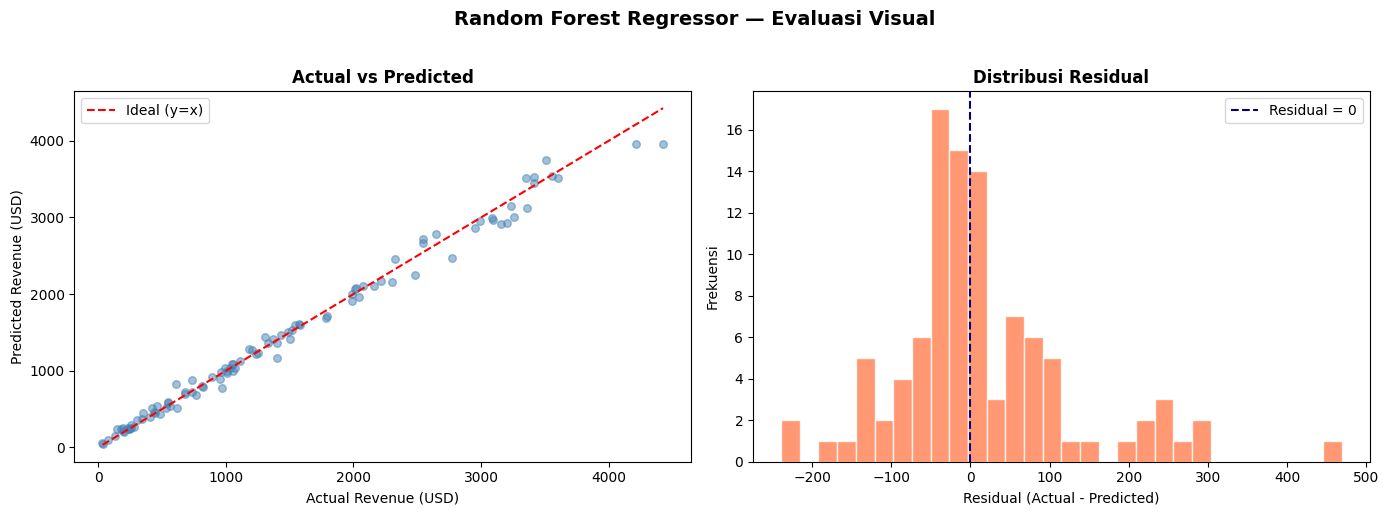

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest Regressor — Evaluasi Visual', fontsize=14, fontweight='bold', y=1.02)

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', s=30)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Ideal (y=x)')
axes[0].set_xlabel('Actual Revenue (USD)')
axes[0].set_ylabel('Predicted Revenue (USD)')
axes[0].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()

# Residual Distribution
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='navy', linestyle='--', lw=1.5, label='Residual = 0')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight Visualisasi Evaluasi:**

**Actual vs Predicted:**
Titik-titik yang sangat rapat mengikuti garis merah (y=x) mengkonfirmasi bahwa prediksi model sangat mendekati nilai aktual. Tidak ada pola sistematik (seperti "model selalu underprediksi di revenue tinggi") yang terlihat, model bekerja baik di seluruh rentang nilai.

**Distribusi Residual:**
Residual (selisih aktual – prediksi) terpusat di sekitar 0 dan berdistribusi mendekati normal. Ini adalah kondisi ideal yang menunjukkan model tidak memiliki **systematic bias**. Ekor sedikit ke kanan menandakan ada beberapa transaksi high-value yang sedikit under-predicted, yang merupakan perilaku wajar.

PCA

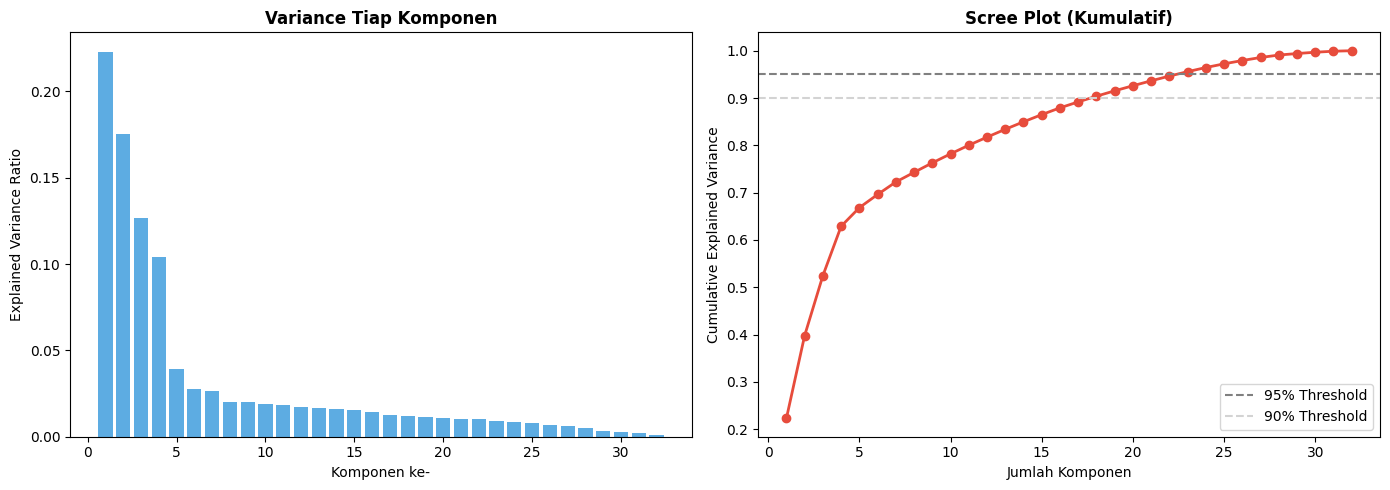

📊 Jumlah fitur awal: 32
   • Untuk 90% variance → cukup 18 komponen
   • Untuk 95% variance → cukup 23 komponen


In [37]:
from sklearn.decomposition import PCA

# ── 1. Scree Plot — Berapa Komponen yang Cukup? ──────────────
pca_full   = PCA(random_state=42).fit(X_train)
var_ratio  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Variance per komponen
axes[0].bar(range(1, len(var_ratio)+1), var_ratio, color='#3498db', alpha=0.8)
axes[0].set_xlabel('Komponen ke-')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance Tiap Komponen', fontsize=12, fontweight='bold')

# (b) Kumulatif
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'o-', color='#e74c3c', lw=2)
axes[1].axhline(y=0.95, color='gray',      linestyle='--', label='95% Threshold')
axes[1].axhline(y=0.90, color='lightgray', linestyle='--', label='90% Threshold')
axes[1].set_xlabel('Jumlah Komponen')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Scree Plot (Kumulatif)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Cari komponen optimal
n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1

print(f'📊 Jumlah fitur awal: {X_train.shape[1]}')
print(f'   • Untuk 90% variance → cukup {n_90} komponen')
print(f'   • Untuk 95% variance → cukup {n_95} komponen')


📊 PCA 2 Komponen:
   • PC1 menjelaskan: 22.30% variance
   • PC2 menjelaskan: 17.50% variance
   • Total          : 39.80% variance


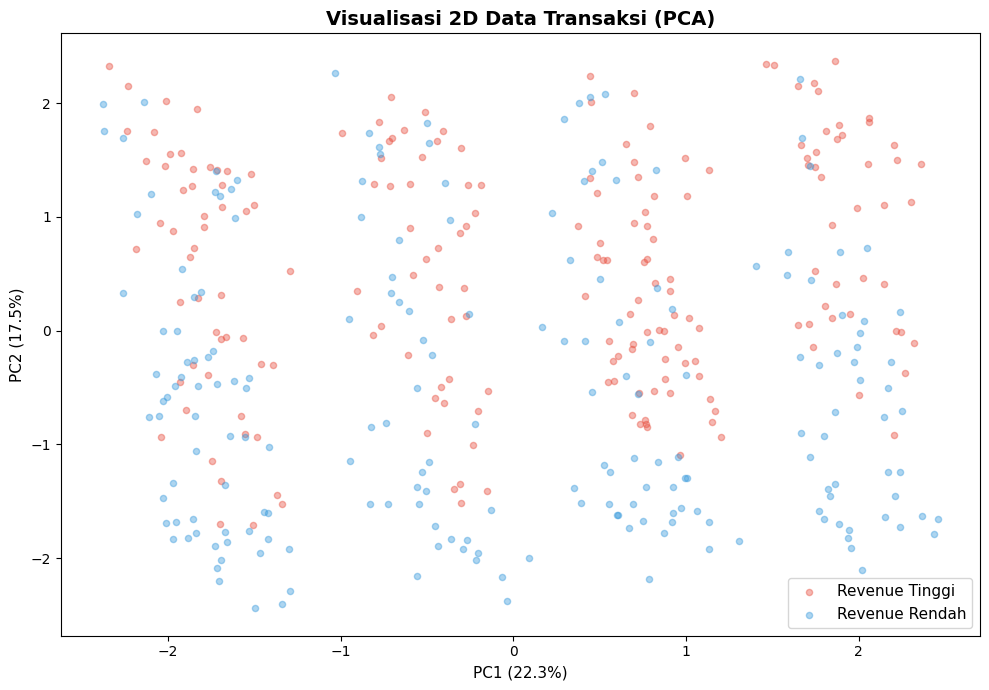

In [38]:
# ── 2. Terapkan PCA (2 Komponen) untuk Visualisasi ────────────
pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_train)

print(f'\n📊 PCA 2 Komponen:')
print(f'   • PC1 menjelaskan: {pca_2d.explained_variance_ratio_[0]:.2%} variance')
print(f'   • PC2 menjelaskan: {pca_2d.explained_variance_ratio_[1]:.2%} variance')
print(f'   • Total          : {pca_2d.explained_variance_ratio_.sum():.2%} variance')

# Visualisasi 2D — warnai berdasarkan Revenue tinggi/rendah
median_rev = y_train.median()
mask_high  = y_train.values >= median_rev
mask_low   = y_train.values <  median_rev

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_pca[mask_high, 0], X_pca[mask_high, 1],
           c='#e74c3c', label='Revenue Tinggi', alpha=0.4, s=20)
ax.scatter(X_pca[mask_low, 0],  X_pca[mask_low, 1],
           c='#3498db', label='Revenue Rendah', alpha=0.4, s=20)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title('Visualisasi 2D Data Transaksi (PCA)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [39]:
# ── 3. Kesimpulan PCA ────────────────────────────────────────
print('\n┌─────────────────────────────────────────────────────┐')
print('│              KESIMPULAN PCA                           │')
print('└─────────────────────────────────────────────────────┘')
print(f"""
  • Data awal memiliki {X_train.shape[1]} fitur
  • Dengan PCA, cukup {n_95} komponen untuk mempertahankan 95% informasi
  • Dari visualisasi 2D terlihat bahwa transaksi Revenue Tinggi dan Rendah
    saling tumpang tindih — ini menunjukkan bahwa prediksi revenue
    membutuhkan lebih dari 2 dimensi untuk dibedakan secara linear
""")


┌─────────────────────────────────────────────────────┐
│              KESIMPULAN PCA                           │
└─────────────────────────────────────────────────────┘

  • Data awal memiliki 32 fitur
  • Dengan PCA, cukup 23 komponen untuk mempertahankan 95% informasi
  • Dari visualisasi 2D terlihat bahwa transaksi Revenue Tinggi dan Rendah
    saling tumpang tindih — ini menunjukkan bahwa prediksi revenue
    membutuhkan lebih dari 2 dimensi untuk dibedakan secara linear



---
## Unsupervised Learning: Customer Segmentation (Clustering)

**Tujuan:** Mengelompokkan transaksi berdasarkan pola `Price_USD`, `Units_Sold`, dan `Revenue_USD` untuk menemukan segmen-segmen yang bermakna secara bisnis.

**Mengapa Clustering?** Berbeda dengan regresi yang supervised, clustering adalah **unsupervised learning**, tidak ada label yang sudah ditentukan. Kita biarkan algoritma menemukan struktur alami dalam data.

**Strategi:** Kita melakukan clustering pada fitur numerik asli (`Price_USD`, `Units_Sold`, `Revenue_USD`) bukan pada fitur yang sudah di encode agar profil cluster mudah diinterpretasi secara bisnis.

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

df_orig_cluster = pd.read_csv('chocolate_sales_2025_dataset.csv')
cluster_features = ['Price_USD', 'Units_Sold', 'Revenue_USD']
X_cluster_raw = df_orig_cluster[cluster_features].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_raw)

In [41]:
# ── 1. Elbow Method & Silhouette Score ────────────────────────
print('📌 Mencari jumlah cluster optimal dengan 2 metode:\n')
print('   1. Elbow Method    — cari \'siku\' di mana penurunan melambat')
print('   2. Silhouette Score — semakin tinggi = cluster semakin bagus\n')

K_range     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

# Tabel hasil
df_eval = pd.DataFrame({
    'K'               : list(K_range),
    'Inertia'         : [f'{v:.1f}' for v in inertias],
    'Silhouette Score': [f'{v:.4f}' for v in silhouettes]
})
display(df_eval)

📌 Mencari jumlah cluster optimal dengan 2 metode:

   1. Elbow Method    — cari 'siku' di mana penurunan melambat
   2. Silhouette Score — semakin tinggi = cluster semakin bagus



,K,Inertia,Silhouette Score
0,2,853.0,0.3803
1,3,537.4,0.3999
2,4,370.8,0.4142
3,5,294.1,0.3978
4,6,246.9,0.3840
5,7,210.4,0.3880
6,8,182.6,0.3837


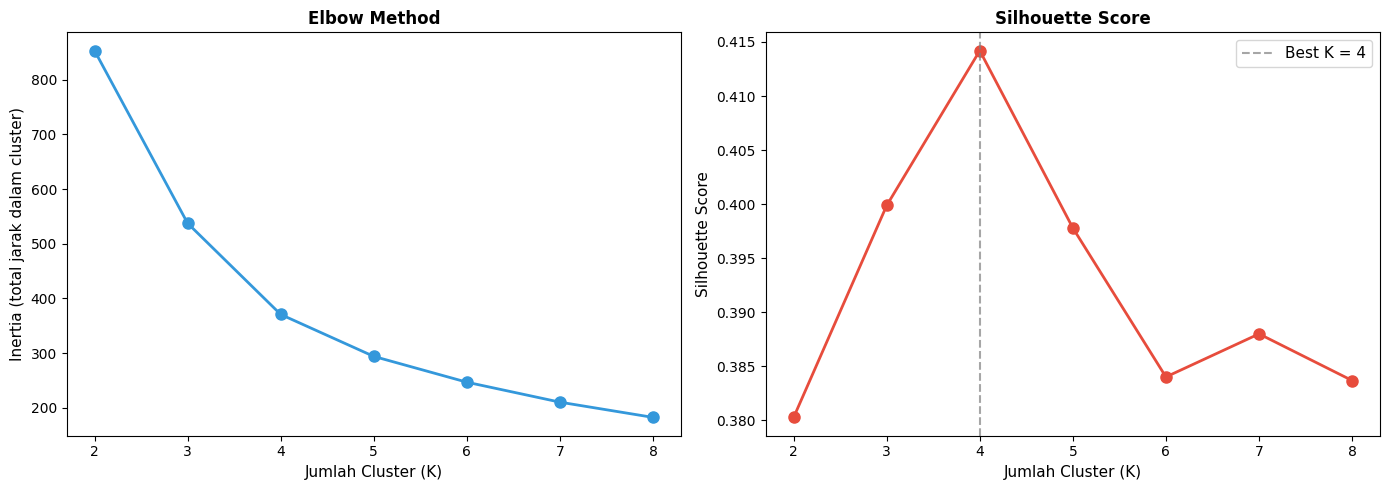


🎯 Jumlah cluster optimal: K = 4
📊 Silhouette Score     : 0.4142
   ⚠️ Moderate — cluster agak tumpang tindih (wajar untuk data transaksi)


In [42]:
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='#3498db', lw=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (K)', fontsize=11)
axes[0].set_ylabel('Inertia (total jarak dalam cluster)', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].set_xticks(list(K_range))

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].plot(K_range, silhouettes, 'o-', color='#e74c3c', lw=2, markersize=8)
axes[1].axvline(x=best_k, color='gray', linestyle='--', alpha=0.7, label=f'Best K = {best_k}')
axes[1].set_xlabel('Jumlah Cluster (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f'\n🎯 Jumlah cluster optimal: K = {best_k}')
print(f'📊 Silhouette Score     : {max(silhouettes):.4f}')

sil = max(silhouettes)
if sil > 0.7:    print('   ✅ Sangat kuat — cluster terpisah jelas')
elif sil > 0.5:  print('   ✅ Baik — cluster cukup terpisah')
elif sil > 0.25: print('   ⚠️ Moderate — cluster agak tumpang tindih (wajar untuk data transaksi)')
else:            print('   ❌ Lemah — data sulit di-cluster')

**Penjelasan Hasil Elbow Method & Silhouette Score:**

Berdasarkan **Elbow Method**, kita mencari titik "siku" di mana penurunan inertia mulai melambat, penambahan cluster tidak lagi memberikan manfaat signifikan dalam memperketat kelompok.

Berdasarkan **Silhouette Score**, kita memilih **K=4** karena menghasilkan nilai tertinggi (~0.4142). Ini berarti pada K=4, titik-titik data rata-rata lebih mirip dengan cluster-nya sendiri dibanding cluster tetangga, pemisahan cluster paling optimal.

Nilai Silhouette Score ~0.41 tergolong **moderate**, yang wajar untuk data transaksi bisnis nyata karena batas antar segmen pelanggan memang tidak selalu tegas (misalnya, pelanggan "mid-range" memiliki karakteristik yang sebagian tumpang tindih dengan "budget" maupun "premium").

In [43]:
# ── 2. Terapkan K-Means dengan K Optimal ──────────────────────
kmeans         = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Tambahkan label cluster ke dataframe asli
df_orig_cluster['Cluster'] = cluster_labels

print(f'Distribusi data per cluster:')
print(df_orig_cluster['Cluster'].value_counts().sort_index())

Distribusi data per cluster:
Cluster
0    116
1    119
2    119
3    146
Name: count, dtype: int64


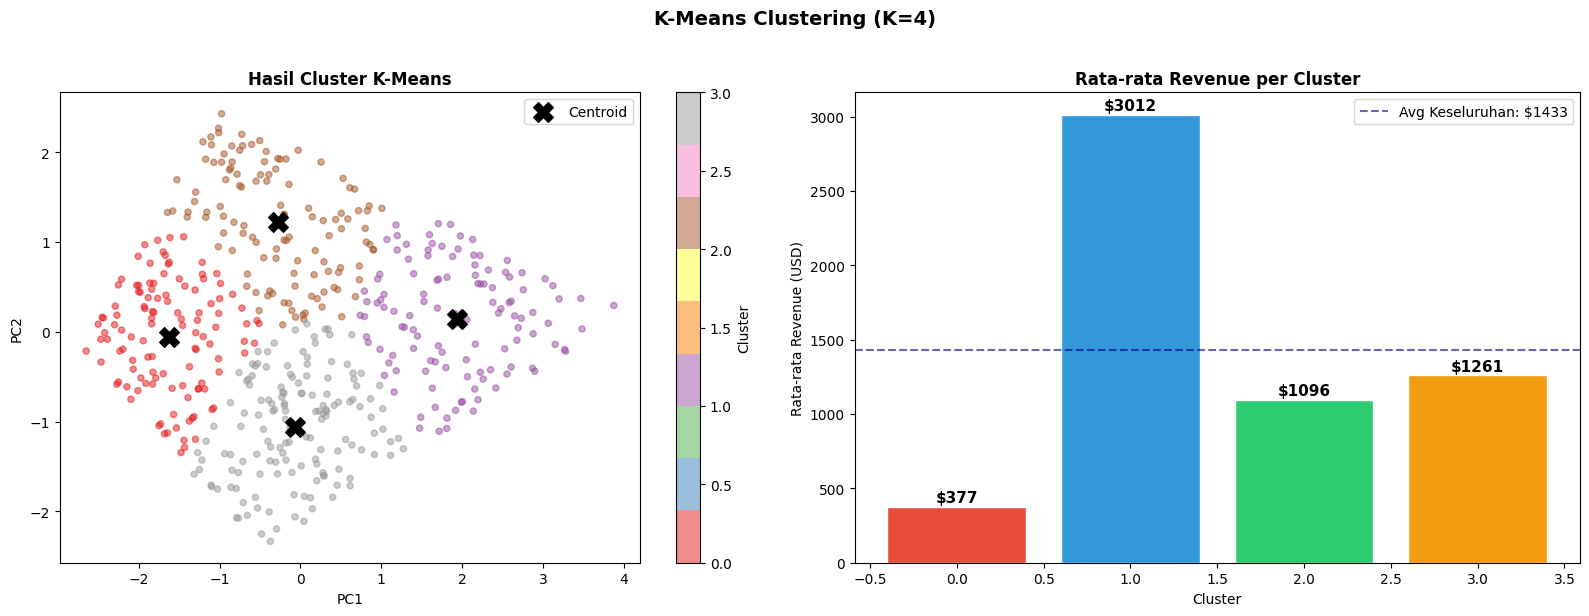

In [44]:
# Visualisasi cluster pada PCA 2D
pca_vis = PCA(n_components=2, random_state=42)
X_vis   = pca_vis.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'K-Means Clustering (K={best_k})', fontsize=14, fontweight='bold', y=1.02)

from matplotlib.lines import Line2D

scatter = axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=cluster_labels,
                          cmap='Set1', alpha=0.5, s=20)
axes[0].set_title('Hasil Cluster K-Means', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Centroid
centroids_vis = pca_vis.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_vis[:, 0], centroids_vis[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroid')
axes[0].legend()

# Revenue per cluster
cluster_rev = df_orig_cluster.groupby('Cluster')['Revenue_USD'].mean()
colors_bar  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:best_k]
bars = axes[1].bar(cluster_rev.index, cluster_rev.values, color=colors_bar, edgecolor='white')
axes[1].axhline(df_orig_cluster['Revenue_USD'].mean(), color='navy', linestyle='--',
                alpha=0.6, label=f'Avg Keseluruhan: ${df_orig_cluster["Revenue_USD"].mean():.0f}')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Rata-rata Revenue (USD)')
axes[1].set_title('Rata-rata Revenue per Cluster', fontsize=12, fontweight='bold')
axes[1].legend()
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 10, f'${h:.0f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


┌─────────────────────────────────────────────────────┐
│              PROFIL TIAP CLUSTER                      │
└─────────────────────────────────────────────────────┘

Cluster 0 (116 transaksi):
  Avg Price   : $8.03
  Avg Units   : 50.2
  Avg Revenue : $377.48
  Top Brand   : Nestle
  Top Product : Chocolate Box

Cluster 1 (119 transaksi):
  Avg Price   : $19.74
  Avg Units   : 154.3
  Avg Revenue : $3012.25
  Top Brand   : Mars
  Top Product : Chocolate Box

Cluster 2 (119 transaksi):
  Avg Price   : $19.54
  Avg Units   : 58.0
  Avg Revenue : $1095.73
  Top Brand   : Lindt
  Top Product : Chocolate Bar

Cluster 3 (146 transaksi):
  Avg Price   : $8.80
  Avg Units   : 146.5
  Avg Revenue : $1260.67
  Top Brand   : Lindt
  Top Product : Chocolate Bar



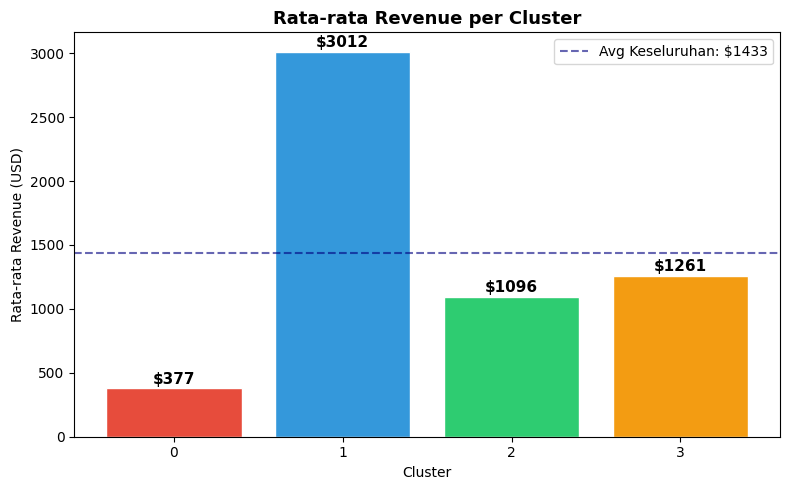

In [45]:
# ── 3. Profil Cluster ─────────────────────────────────────────
print('\n┌─────────────────────────────────────────────────────┐')
print('│              PROFIL TIAP CLUSTER                      │')
print('└─────────────────────────────────────────────────────┘\n')

for c in range(best_k):
    sub       = df_orig_cluster[df_orig_cluster['Cluster'] == c]
    avg_price = sub['Price_USD'].mean()
    avg_units = sub['Units_Sold'].mean()
    avg_rev   = sub['Revenue_USD'].mean()
    top_brand = sub['Brand'].value_counts().index[0]
    top_prod  = sub['Product_Type'].value_counts().index[0]
    print(f'Cluster {c} ({len(sub)} transaksi):')
    print(f'  Avg Price   : ${avg_price:.2f}')
    print(f'  Avg Units   : {avg_units:.1f}')
    print(f'  Avg Revenue : ${avg_rev:.2f}')
    print(f'  Top Brand   : {top_brand}')
    print(f'  Top Product : {top_prod}')
    print()

avg_rev_all = df_orig_cluster['Revenue_USD'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
avg_revenues = df_orig_cluster.groupby('Cluster')['Revenue_USD'].mean()
colors_bar   = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:best_k]
bars = ax.bar(avg_revenues.index, avg_revenues.values, color=colors_bar, edgecolor='white')
ax.axhline(avg_rev_all, color='navy', linestyle='--', alpha=0.6,
           label=f'Avg Keseluruhan: ${avg_rev_all:.0f}')
ax.set_xlabel('Cluster')
ax.set_ylabel('Rata-rata Revenue (USD)')
ax.set_title('Rata-rata Revenue per Cluster', fontsize=13, fontweight='bold')
ax.set_xticks(range(best_k))
ax.legend()
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 10, f'${h:.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**📊 Penjelasan Hasil Clustering:**

Berdasarkan **Elbow Method** dan **Silhouette Score**, kami memilih **K=4** sebagai jumlah cluster optimal. Berikut interpretasi bisnis dari masing-masing cluster berdasarkan profil rata-rata:

---

🟢 **Cluster 0 — "Small Budget Buyer" (Harga Rendah, Volume Rendah)**
- Avg Price ~\$8.03 | Avg Units ~50 unit | Avg Revenue ~\$377
- Kelompok ini adalah transaksi **skala kecil dengan produk murah**. Kemungkinan pembelian eceran atau toko kecil yang membeli dalam jumlah terbatas. Revenue rendah karena kombinasi harga murah dan volume kecil.

---

🔴 **Cluster 1 — "High Volume Premium Buyer" (Harga Tinggi, Volume Tinggi)**
- Avg Price ~\$19.74 | Avg Units ~154 unit | Avg Revenue ~\$3.012
- Kelompok ini adalah transaksi **bernilai tinggi** — pembeli yang membeli produk premium dalam jumlah besar. Kemungkinan distributor atau retailer besar yang memesan coklat premium (Lindt, Ferrero) dalam kuantitas tinggi.

---

🟡 **Cluster 2 — "Premium Low Volume" (Harga Tinggi, Volume Rendah)**
- Avg Price ~\$19.54 | Avg Units ~58 unit | Avg Revenue ~\$1.096
- Kelompok ini membeli **produk premium namun dalam jumlah terbatas**. Kemungkinan toko specialty atau pembeli korporat yang membeli coklat mahal sebagai hadiah atau souvenir dalam jumlah tidak terlalu besar.

---

🔵 **Cluster 3 — "Budget Bulk Buyer" (Harga Rendah, Volume Tinggi)**
- Avg Price ~\$8.80 | Avg Units ~147 unit | Avg Revenue ~\$1.261
- Kelompok ini membeli **produk murah dalam volume besar**. Kemungkinan supermarket atau convenience store yang menjual coklat sebagai produk mass-market dengan margin tipis namun volume tinggi.

---

**Implikasi Bisnis:**
- **Cluster 1** adalah segmen paling bernilai — strategi retensi dan loyalty program perlu diprioritaskan
- **Cluster 3** memiliki potensi upselling — tawarkan produk mid-range untuk meningkatkan revenue per transaksi
- **Cluster 0** perlu strategi akuisisi volume — berikan insentif pembelian dalam jumlah lebih besar

In [46]:
import joblib
print('joblib imported successfully.')

joblib imported successfully.


In [47]:
joblib.dump(scaler, 'scaler.joblib')
print("StandardScaler object saved to 'scaler.joblib'.")

StandardScaler object saved to 'scaler.joblib'.


In [48]:
joblib.dump(best_rf, 'best_rf_model.joblib')
print("Tuned Random Forest model saved to 'best_rf_model.joblib'.")

Tuned Random Forest model saved to 'best_rf_model.joblib'.


In [49]:
joblib.dump(kmeans, 'kmeans_model.joblib')
print("K-Means model saved to 'kmeans_model.joblib'.")

K-Means model saved to 'kmeans_model.joblib'.


In [50]:
joblib.dump(X_train.columns, 'feature_columns.joblib')
print("Feature column names saved to 'feature_columns.joblib'.")

Feature column names saved to 'feature_columns.joblib'.
